In [1]:
import os
import random
import glob
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_addons as tfa
import matplotlib.pyplot as plt
import cv2
import numpy as np

print("GPUs:", tf.config.list_physical_devices('GPU'))

IMG_DIR = "../grayscale_frames"
MASK_DIR = "../mask_frames"
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
EPOCHS = 100
MODEL_SAVE_PATH = "segmentation_unet.h5"

CLASS_COLORS = {
    1: [255,   0,   0],   # ship -> red
    2: [128, 128, 128],   # sargassum -> gray
    3: [255, 255, 255],   # oil -> white
}
NUM_CLASSES = 1 + len(CLASS_COLORS)  # background (0) + classes

2025-10-06 14:32:21.616574: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-06 14:32:21.639345: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-06 14:32:21.639364: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-06 14:32:21.639369: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-06 14:32:21.642870: I tensorflow/core/platform/cpu_feature_g

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2025-10-06 14:32:22.857812: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-10-06 14:32:22.879840: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-10-06 14:32:22.882736: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [2]:
def add_blank_chance(img, mask, prob=0.1):
    def make_blank():
        color = tf.constant([148/255.0, 208/255.0, 232/255.0], dtype=tf.float32)
        color = tf.reduce_mean(color)
        blank_img = tf.ones([IMG_SIZE[0], IMG_SIZE[1], 1], dtype=tf.float32) * color
        blank_mask = tf.zeros([IMG_SIZE[0], IMG_SIZE[1], 1], dtype=tf.int32)
        return blank_img, blank_mask

    do_blank = tf.random.uniform([]) < prob
    img, mask = tf.cond(do_blank, make_blank, lambda: (img, mask))
    return img, mask

def apply_blur(img, max_sigma=3.0):
    sigma = tf.random.uniform([], 0.0, max_sigma)

    sigma_x = tf.cast(sigma, tf.float32)
    sigma_y = tf.cast(sigma, tf.float32)

    def _blur_eager(image, sx, sy):
        image = tf.convert_to_tensor(image)
        return tfa.image.gaussian_filter2d(image, filter_shape=(9, 9), sigma=(float(sx), float(sy)))

    blurred = tf.py_function(_blur_eager, [img, sigma_x, sigma_y], tf.float32)
    blurred.set_shape(img.shape)
    return blurred

def list_image_mask_pairs(img_dir, mask_dir):
    imgs = sorted(glob.glob(os.path.join(img_dir, "*.png")))
    masks = sorted(glob.glob(os.path.join(mask_dir, "*.png")))
    # Keep only pairs where filenames match by number of items (assumes ordering aligns)
    if len(imgs) != len(masks):
        print(f"Warning: {len(imgs)} images vs {len(masks)} masks. Pairing by min length.")
    n = min(len(imgs), len(masks))
    return imgs[:n], masks[:n]

def py_parse_image_mask(img_path_bytes, mask_path_bytes, size=IMG_SIZE):
    """
    Pure-Python / NumPy function to read files using OpenCV and return:
      img -> float32 array shape (H, W, 1) scaled [0,1]
      class_mask -> int32 array shape (H, W) with class ids (0..)
    This function will be called via tf.numpy_function (so it receives bytes).
    """
    # decode bytes -> str paths
    img_path = img_path_bytes.decode() if isinstance(img_path_bytes, bytes) else img_path_bytes
    mask_path = mask_path_bytes.decode() if isinstance(mask_path_bytes, bytes) else mask_path_bytes

    # read grayscale input
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {img_path}")
    # resize: cv2.resize expects (width, height)
    img = cv2.resize(img, (size[1], size[0]), interpolation=cv2.INTER_LINEAR)
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)  # (H, W, 1)

    # read mask (color)
    mask_color = cv2.imread(mask_path, cv2.IMREAD_COLOR)  # returns BGR
    if mask_color is None:
        raise FileNotFoundError(f"Could not read mask: {mask_path}")
    # convert BGR -> RGB
    mask_color = mask_color[..., ::-1]
    mask_color = cv2.resize(mask_color, (size[1], size[0]), interpolation=cv2.INTER_NEAREST)
    mask_color = mask_color.astype(np.uint8)

    # build class mask
    class_mask = np.zeros((size[0], size[1]), dtype=np.int32)  # background = 0
    for class_id, rgb in CLASS_COLORS.items():
        rgb = np.array(rgb, dtype=np.uint8)  # [R,G,B]
        matches = np.all(mask_color == rgb[None, None, :], axis=-1)
        class_mask[matches] = int(class_id)

    return img.astype(np.float32), class_mask.astype(np.int32)

def parse_image_mask_tf(img_path, mask_path):
    # returns img: float32 (H,W,1), mask: int32 (H,W)
    img, mask = tf.numpy_function(func=py_parse_image_mask,
                                  inp=[img_path, mask_path],
                                  Tout=[tf.float32, tf.int32])
    # Tell TF the exact shapes and dtypes (important!)
    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 1])   # (H, W, 1)
    mask.set_shape([IMG_SIZE[0], IMG_SIZE[1]])     # (H, W)
    return img, mask

def elastic_deform(img, mask, alpha=30, sigma=4, num_points=8):
    """Apply elastic deformation using sparse_image_warp."""
    shape = tf.shape(img)[:2]

    # random control points
    points = tf.random.uniform([num_points, 2], 0, tf.cast(shape[0], tf.float32))
    offsets = tf.random.normal([num_points, 2], stddev=sigma) * alpha

    # warp image (already float32)
    img_warped, _ = tfa.image.sparse_image_warp(
        img[None], points[None], points[None] + offsets[None]
    )

    # warp mask (must be float32 first!)
    mask_f = tf.cast(mask, tf.float32)
    mask_warped, _ = tfa.image.sparse_image_warp(
        mask_f[None], points[None], points[None] + offsets[None]
    )

    # round back to int
    mask_warped = tf.cast(tf.round(mask_warped[0]), tf.int32)
    return img_warped[0], mask_warped

# Data augmentation (optional, light)
def augment(img, mask):
    img, mask = add_blank_chance(img, mask, prob=0.25)

    # horizontal flip
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    # rotation 0/90/180/270
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    mask = tf.image.rot90(mask, k)

    # brightness & contrast
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.8, 1.2)

    # random blur (simulate motion / focus issues)
    if tf.random.uniform([]) < 0.2:  # 20% chance
        img = apply_blur(img, max_sigma=3.0)

    # gaussian noise
    noise = tf.random.normal(tf.shape(img), mean=0.0, stddev=0.02)
    img = tf.clip_by_value(img + noise, 0.0, 1.0)

    # elastic deformation (10% chance)
    do_elastic = tf.random.uniform([], 0, 1.0) > 0.9
    img, mask = tf.cond(
        do_elastic,
        lambda: elastic_deform(img, mask),
        lambda: (img, mask)
    )

    # random zoom / scale
    scale = tf.random.uniform([], 0.8, 1.2)
    new_size = tf.cast(tf.cast(tf.shape(img)[:2], tf.float32) * scale, tf.int32)
    img = tf.image.resize(img, new_size, method="bilinear")
    mask = tf.image.resize(mask, new_size, method="nearest")
    img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE[0], IMG_SIZE[1])
    mask = tf.image.resize_with_crop_or_pad(mask, IMG_SIZE[0], IMG_SIZE[1])

    # random translation
    max_shift = 10
    dx = tf.random.uniform([], -max_shift, max_shift, dtype=tf.int32)
    dy = tf.random.uniform([], -max_shift, max_shift, dtype=tf.int32)
    img = tfa.image.translate(img, [dx, dy], fill_mode='REFLECT')
    mask = tfa.image.translate(mask, [dx, dy], fill_mode='CONSTANT')

    # random cutout
    mask_holes = tf.cast(tf.random.uniform([IMG_SIZE[0], IMG_SIZE[1], 1]) > 0.95, tf.float32)
    img = img * (1 - mask_holes)

    return img, mask

# Build tf.data dataset
def make_dataset(img_paths, mask_paths, batch, shuffle=True, augment_fn=None):
    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(img_paths))

    # use the TF wrapper that returns img (H,W,1) and mask (H,W,1) or (H,W)
    ds = ds.map(parse_image_mask_tf, num_parallel_calls=AUTOTUNE)

    # ensure shapes (parse wrapper already sets shapes, but keep this)
    def set_shapes(img, mask):
        img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 1])
        # mask might be (H,W) or (H,W,1) depending on parse; normalize to (H,W,1)
        if mask.shape.rank == 2:
            mask = tf.expand_dims(mask, -1)
        mask.set_shape([IMG_SIZE[0], IMG_SIZE[1], 1])
        return img, mask
    ds = ds.map(set_shapes, num_parallel_calls=AUTOTUNE)

    # apply augmentations (augment expects mask (H,W,1))
    if augment_fn is not None:
        ds = ds.map(lambda x, y: augment_fn(x, y), num_parallel_calls=AUTOTUNE)

    # After augmentation: convert mask from (H,W,1) -> (H,W) because loss expects 2D labels
    ds = ds.map(lambda x, y: (x, tf.cast(tf.squeeze(y, axis=-1), tf.int32)),
                num_parallel_calls=AUTOTUNE)

    ds = ds.batch(batch).prefetch(AUTOTUNE)
    return ds


# ----- model: simple U-Net -----
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x

def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPooling2D((2,2))(c)
    return c, p

def decoder_block(x, skip, filters):
    x = layers.UpSampling2D((2,2))(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)
    # Encoder
    c1, p1 = encoder_block(inputs, 32)
    c2, p2 = encoder_block(p1, 64)
    c3, p3 = encoder_block(p2, 128)
    c4, p4 = encoder_block(p3, 256)

    b = conv_block(p4, 512)

    d4 = decoder_block(b, c4, 256)
    d3 = decoder_block(d4, c3, 128)
    d2 = decoder_block(d3, c2, 64)
    d1 = decoder_block(d2, c1, 32)

    outputs = layers.Conv2D(num_classes, 1, padding="same", activation="softmax")(d1)  # per-pixel class probs
    model = keras.Model(inputs, outputs)
    return model

# Simple IoU metric for multiclass (average over classes, excluding background optionally)
def sparse_iou(y_true, y_pred, num_classes=NUM_CLASSES):
    # y_true: (B,H,W) int32, y_pred: (B,H,W,num_classes) float
    y_pred_labels = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
    y_true = tf.cast(y_true, tf.int32)

    ious = []
    for cls in range(1, num_classes):  # skip background (cls=0) or include
        pred_pos = tf.equal(y_pred_labels, cls)
        true_pos = tf.equal(y_true, cls)
        intersection = tf.reduce_sum(tf.cast(tf.logical_and(pred_pos, true_pos), tf.float32))
        union = tf.reduce_sum(tf.cast(tf.logical_or(pred_pos, true_pos), tf.float32))
        iou = tf.cond(tf.equal(union, 0), lambda: tf.constant(1.0), lambda: intersection / union)
        ious.append(iou)
    return tf.reduce_mean(tf.stack(ious))

class IoUCallback(keras.metrics.Metric):
    def __init__(self, name="mean_iou", **kwargs):
        super().__init__(name=name, **kwargs)
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        iou = sparse_iou(y_true, y_pred)
        self.total.assign_add(iou)
        self.count.assign_add(1.0)

    def result(self):
        return self.total / self.count

    def reset_state(self):
        self.total.assign(0.0)
        self.count.assign(0.0)

In [3]:
img_paths, mask_paths = list_image_mask_pairs(IMG_DIR, MASK_DIR)
if len(img_paths) == 0:
    raise RuntimeError("No image-mask pairs found. Check paths.")

# split train/val
paired = list(zip(img_paths, mask_paths))
random.shuffle(paired)
n = len(paired)
n_val = max(1, int(0.15 * n))
train_pairs = paired[:-n_val]
val_pairs = paired[-n_val:]

train_img, train_mask = zip(*train_pairs)
val_img, val_mask = zip(*val_pairs)

train_ds = make_dataset(list(train_img), list(train_mask), BATCH_SIZE, shuffle=True, augment_fn=augment)
val_ds = make_dataset(list(val_img), list(val_mask), BATCH_SIZE, shuffle=False, augment_fn=None)

2025-10-06 14:32:22.919877: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-10-06 14:32:22.922753: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-10-06 14:32:22.926464: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

2025-10-06 14:32:25.368658: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907


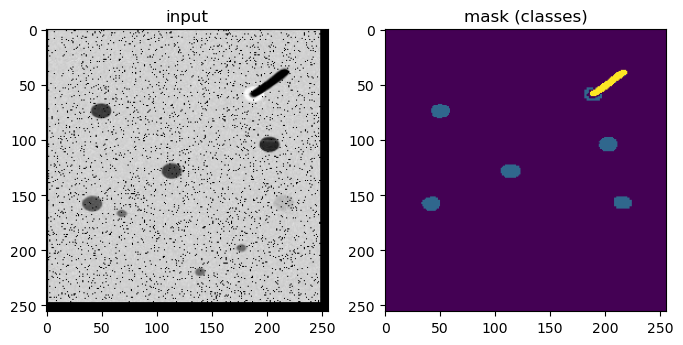

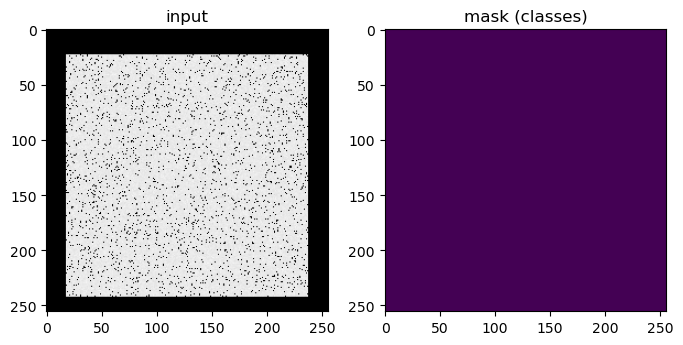

In [4]:
for img, mask in train_ds.take(2):
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1); plt.imshow(img[0,:,:,0], cmap='gray'); plt.title('input')
    plt.subplot(1,2,2); plt.imshow(mask[0,:,:]); plt.title('mask (classes)')
    plt.show()

In [5]:
def augment_graph(img, mask):
    # Ensure mask has channel dim for image ops
    mask = tf.cond(tf.equal(tf.rank(mask), 2),
                   lambda: tf.expand_dims(mask, axis=-1),
                   lambda: mask)  # now mask is (H,W,1)

    # Random horizontal flip
    do_flip = tf.random.uniform([]) > 0.5
    img = tf.cond(do_flip, lambda: tf.image.flip_left_right(img), lambda: img)
    mask = tf.cond(do_flip, lambda: tf.image.flip_left_right(mask), lambda: mask)

    # Random brightness (image only)
    do_bright = tf.random.uniform([]) > 0.9
    img = tf.cond(do_bright, lambda: tf.image.random_brightness(img, 0.1), lambda: img)

    return img, mask  # mask still (H,W,1)

def make_dataset_fixed(img_paths, mask_paths, batch, shuffle=True, augment_fn=None):
    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(img_paths))

    # map loader
    ds = ds.map(parse_image_mask_tf, num_parallel_calls=AUTOTUNE)

    # After loader, img: (H,W,1), mask: (H,W)
    # Normalize shapes explicitly (helps TF know ranks)
    def enforce_shapes(img, mask):
        img = tf.ensure_shape(img, [IMG_SIZE[0], IMG_SIZE[1], 1])
        mask = tf.ensure_shape(mask, [IMG_SIZE[0], IMG_SIZE[1]])
        return img, mask
    ds = ds.map(enforce_shapes, num_parallel_calls=AUTOTUNE)

    # Augment (expects mask (H,W) or (H,W,1) — augment_graph handles it)
    if augment_fn is not None:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
        # After augment, mask is (H,W,1). Ensure shape:
        def ensure_after_aug(img, mask):
            mask = tf.ensure_shape(mask, [IMG_SIZE[0], IMG_SIZE[1], 1])
            img = tf.ensure_shape(img, [IMG_SIZE[0], IMG_SIZE[1], 1])
            return img, mask
        ds = ds.map(ensure_after_aug, num_parallel_calls=AUTOTUNE)

        # Squeeze mask to (H,W) because loss expects 2D integer labels
        def squeeze_mask(img, mask):
            mask_s = tf.squeeze(mask, axis=-1)
            mask_s = tf.cast(mask_s, tf.int32)
            mask_s = tf.ensure_shape(mask_s, [IMG_SIZE[0], IMG_SIZE[1]])
            return img, mask_s
        ds = ds.map(squeeze_mask, num_parallel_calls=AUTOTUNE)

    # If no augment_fn, ensure mask dtype is int32
    else:
        def cast_mask(img, mask):
            mask = tf.cast(mask, tf.int32)
            return img, mask
        ds = ds.map(cast_mask, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(batch)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [6]:
train_ds = make_dataset_fixed(list(train_img), list(train_mask), BATCH_SIZE, shuffle=True, augment_fn=augment_graph)
val_ds   = make_dataset_fixed(list(val_img),   list(val_mask),   BATCH_SIZE, shuffle=False, augment_fn=None)

# Debug: print element_spec to verify everything is concrete
print("train_ds.element_spec:", train_ds.element_spec)
print("val_ds.element_spec:  ", val_ds.element_spec)

model = build_unet()
model.summary()

loss = keras.losses.SparseCategoricalCrossentropy()
iou_metric = IoUCallback()

model.compile(optimizer=keras.optimizers.Adam(1e-4), loss=loss, metrics=[iou_metric, "accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_loss", verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=4, factor=0.5, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
]

model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

# Save final model
model.save(MODEL_SAVE_PATH)
print("Saved model to", MODEL_SAVE_PATH)


train_ds.element_spec: (TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256), dtype=tf.int32, name=None))
val_ds.element_spec:   (TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256), dtype=tf.int32, name=None))
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 1)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 32)         320       ['input_1[0][0]']             
                                                                                                  
 conv2d_1 (Conv2D)           (None, 256, 256, 32)         9248      ['conv2d[0][0

2025-10-06 14:32:30.396602: W tensorflow/compiler/xla/service/gpu/llvm_gpu_backend/gpu_backend_lib.cc:521] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  /usr/local/cuda-11.8
  /usr/local/cuda
  /home/vinicius/anaconda3/envs/mancha/lib/python3.10/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /home/vinicius/anaconda3/envs/mancha/lib/python3.10/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
  .
You can choose the search directory by setting xla_gpu_cuda_data_dir in HloModule's DebugOptions.  For most apps, setting the environment variable XLA_FLAGS=--xla_gpu_cuda_data_dir=/path/to/cuda will work.
2025-10-06 14:32:30.776810: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x78a40523e260 initialized for platform CUDA (this does not guarantee th

86/86 [==============================] - ETA: 0s - loss: 0.3918 - mean_iou: 0.1567 - accuracy: 0.9164
Epoch 1: val_loss improved from inf to 0.09976, saving model to best_model.h5
86/86 [==============================] - 62s 532ms/step - loss: 0.3918 - mean_iou: 0.1567 - accuracy: 0.9164 - val_loss: 0.0998 - val_mean_iou: 0.3333 - val_accuracy: 0.9783 - lr: 1.0000e-04
Epoch 2/100


/home/vinicius/anaconda3/envs/mancha/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


86/86 [==============================] - ETA: 0s - loss: 0.0621 - mean_iou: 0.3670 - accuracy: 0.9801
Epoch 2: val_loss improved from 0.09976 to 0.02908, saving model to best_model.h5
86/86 [==============================] - 35s 407ms/step - loss: 0.0621 - mean_iou: 0.3670 - accuracy: 0.9801 - val_loss: 0.0291 - val_mean_iou: 0.5034 - val_accuracy: 0.9870 - lr: 1.0000e-04
Epoch 3/100
86/86 [==============================] - ETA: 0s - loss: 0.0211 - mean_iou: 0.7846 - accuracy: 0.9921
Epoch 3: val_loss improved from 0.02908 to 0.01036, saving model to best_model.h5
86/86 [==============================] - 35s 411ms/step - loss: 0.0211 - mean_iou: 0.7846 - accuracy: 0.9921 - val_loss: 0.0104 - val_mean_iou: 0.8970 - val_accuracy: 0.9959 - lr: 1.0000e-04
Epoch 4/100
86/86 [==============================] - ETA: 0s - loss: 0.0089 - mean_iou: 0.9074 - accuracy: 0.9964
Epoch 4: val_loss improved from 0.01036 to 0.00713, saving model to best_model.h5
86/86 [==============================] - 3